In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def simulation_1(n,p,w1,m1,m2,sigma1,sigma2):
    mu1 = np.full(p, m1)
    mu2 = np.full(p, m2)
    Sigma1 = np.full((p,p),0.8)
    np.fill_diagonal(Sigma1,1)
    Sigma1 = Sigma1 * sigma1
    Sigma2 = np.eye(p) * sigma2
    X = np.zeros((n,p))
    n1 = int(n * w1)
    n2 = n-n1
    X[:n1,:] = np.random.multivariate_normal(mu1, Sigma1, size=n1)
    X[n1:,:] = np.random.multivariate_normal(mu2, Sigma2, size=n2)
    np.random.shuffle(X)
    epsilon = np.random.normal(0, 1, size=n)
    beta = np.random.normal(0, 1, size=p)
    Y = np.dot(X, beta) + epsilon
    return X, Y, beta
X,Y,beta = simulation_1(8192,250,0.01,3,0,0.01,1)

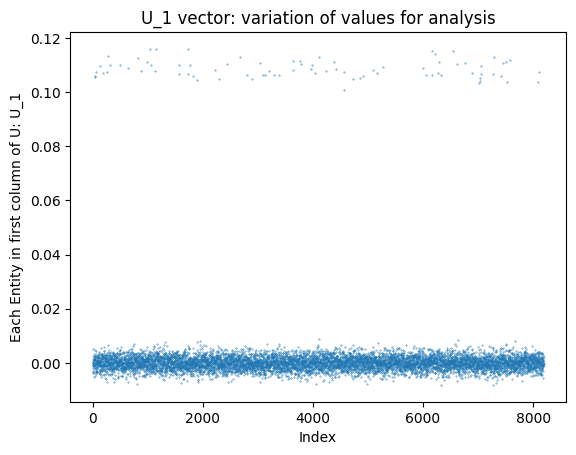

In [3]:
# Compute the singular decomposition of matrix X, X = (U)(Σ)(V^T)
U, s, Vh = np.linalg.svd(X)
# U_1 is the first column of matrix U, which represents the principal direction of variation in X
U_1 = U[:, 0]

# Plot singular values using a dot plot
plt.scatter(range(len(U_1)), U_1,s = 0.1)
plt.xlabel('Index')
plt.ylabel('Each Entity in first column of U: U_1')
plt.title('U_1 vector: variation of values for analysis')
plt.show()

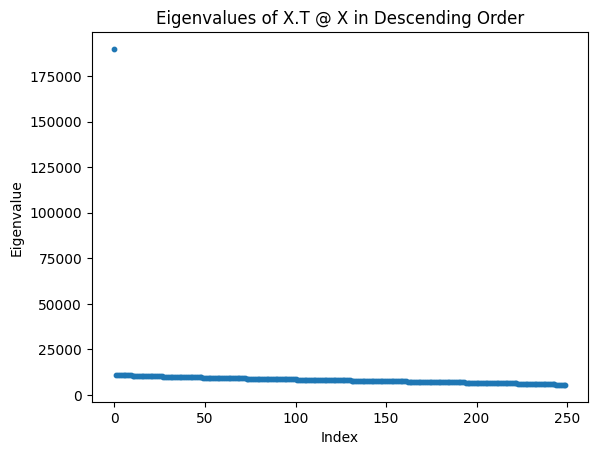

In [4]:
# Since X is non-square (8192 x 250), we compute the eigenvalue decomposition of X.T @ X (a 250 x 250 matrix)
eigvals, eigvecs = np.linalg.eig(X.T @ X)

# Sort eigenvalues in descending order
sorted_eigvals = np.sort(eigvals)[::-1]

# Scatter plot of the sorted eigenvalues
plt.scatter(range(len(sorted_eigvals)), sorted_eigvals, s=10)
plt.xlabel("Index")
plt.ylabel("Eigenvalue")
plt.title("Eigenvalues of X.T @ X in Descending Order")
plt.show()